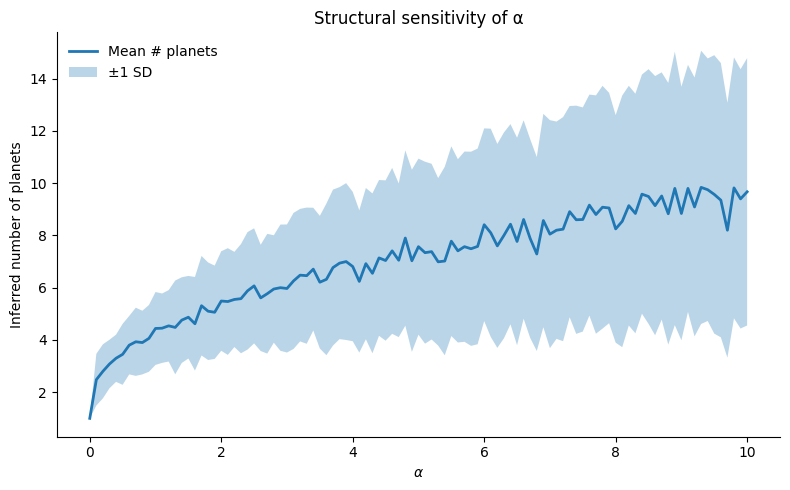

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv("C:/Users/zyfxl/OneDrive - UC Irvine/UCI/CCNL Lab/Foraging Task Overview/foraging_MQLP-main/foraging_MQLP-main/model/simulations/results_alpha_bins/alpha_planet_summary.csv")

alpha = df["alpha"]
meanK = df["meanK"]
stdK  = np.sqrt(df["varK"])

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(alpha, meanK, lw=2, label="Mean # planets")
ax.fill_between(alpha, meanK - stdK, meanK + stdK, alpha=0.3, label="±1 SD")

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Inferred number of planets")
ax.set_title("Structural sensitivity of α")

ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


C:\Users\zyfxl\AppData\Local\Temp\ipykernel_47088\2918174157.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("alpha_bin")


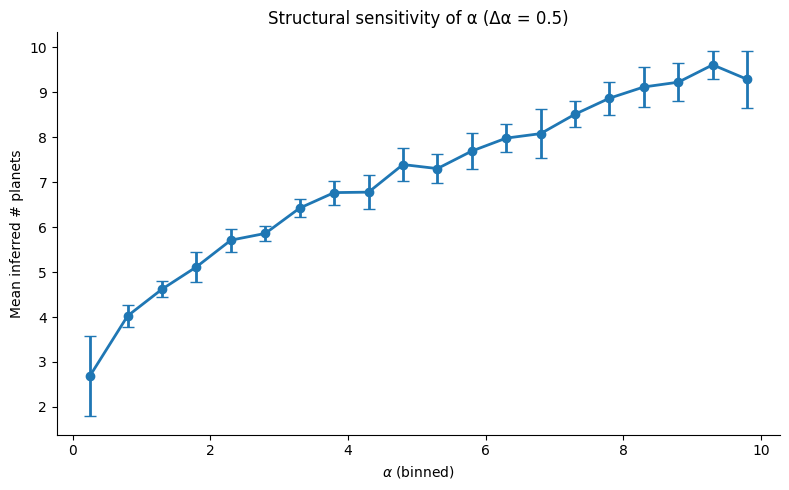

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Define alpha bins
bin_width = 0.5
bins = np.arange(0, df["alpha"].max() + bin_width, bin_width)

df["alpha_bin"] = pd.cut(df["alpha"], bins=bins, include_lowest=True)

# Aggregate within bins
binned = (
    df.groupby("alpha_bin")
      .agg(
          alpha_center=("alpha", "mean"),
          meanK=("meanK", "mean"),
          stdK=("meanK", "std")
      )
      .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    binned["alpha_center"],
    binned["meanK"],
    yerr=binned["stdK"],
    fmt="o-",
    capsize=4,
    lw=2
)

ax.set_xlabel(r"$\alpha$ (binned)")
ax.set_ylabel("Mean inferred # planets")
ax.set_title("Structural sensitivity of α (Δα = 0.5)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
